# POD-DeepONet

In [ ]:
import os
import h5py
import sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from utils.datasets import load
from models.pod import PODTrainer, PODConfig
from models.pod_deeponet import BranchNet, PODDeepONet, PODDeepONetConfig, PODDeepONetTrainer

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

def rel_l2(true, pred):
    return np.linalg.norm(true - pred, axis=1) / np.linalg.norm(true, axis=1)

*(Lu et al., 2022)*

**Problem.** Given initial condition $u_0(x) = u(x, 0)$, approximate the
solution operator $\mathcal{G}: u_0 \mapsto u(\cdot, \cdot)$ for a
time-dependent PDE on domain $x \in \Omega$, $t \in [0, T]$.

#### Phase 1: Proper Orthogonal Decomposition

Let $\{u^n\}_{n=1}^N$ be training trajectories. Each trajectory is represented
as a vector $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$ by flattening the
spatiotemporal grid.


Compute the mean field:
$$\bar{u} = \frac{1}{N} \sum_{n=1}^N \mathbf{s}^n \in \mathbb{R}^{N_t N_x}$$

Apply SVD to the centered snapshot matrix $S \in \mathbb{R}^{N \times N_t N_x}$:
$$S - \bar{u} = U \Sigma V^\top$$

Retain the $P$ leading right singular vectors as POD modes:
$$\Phi = V_{:, 1:P} \in \mathbb{R}^{N_t N_x \times P}$$

The projection coefficients for each training trajectory are:
$$\boldsymbol{\beta}^n = (\mathbf{s}^n - \bar{u})\, \Phi \in \mathbb{R}^P$$

The modes $\Phi$ are fixed after this step. $P$ is chosen so that the retained
modes explain a prescribed fraction of total variance

#### Phase 2: Branch Network

A fully connected network $\mathcal{B}_\theta: \mathbb{R}^m \to \mathbb{R}^P$
is trained to predict the POD coefficients from the initial condition sampled
at $m$ sensor points $\{x_j\}_{j=1}^m$:
$$\hat{\boldsymbol{\beta}} = \mathcal{B}_\theta\bigl(u_0(x_1), \ldots, u_0(x_m)\bigr)$$

Training minimizes the mean squared error against Phase 1 coefficients:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{n=1}^N
\bigl\| \mathcal{B}_\theta(u_0^n) - \boldsymbol{\beta}^n \bigr\|_2^2$$

The POD modes $\Phi$ are not updated during this phase.

---

#### Prediction

For a new initial condition $u_0^*$, the full solution is approximated as:
$$\hat{u}(x, t) = \bar{u}(x, t) + \mathcal{B}_\theta(u_0^*)\, \Phi^\top$$

The result is reshaped from $\mathbb{R}^{N_t N_x}$ to the spatiotemporal grid
$(N_t, N_x)$. The branch is evaluated once, and reconstruction is a single
matrix-vector product 


### Data loading

In [2]:
_local  = pathlib.Path("..") / "data" / "Burgers_Nu0.01.hdf5"
_server = pathlib.Path(os.path.expanduser("~/data/1D/Burgers/Train")) / "1D_Burgers_Sols_Nu0.01.hdf5"
path = str(_local) if _local.exists() else str(_server)
print(f"data: {path}")

N_train, N_test = 9000, 500

with h5py.File(path, "r") as f:
    raw = f["tensor"][:N_train + N_test]
    if raw.ndim == 4:
        raw = raw[..., 0]
    x_np = f["x-coordinate"][:]
    t_np = f["t-coordinate"][:]

N_total, Nt, Nx = raw.shape
print(f"loaded: N={N_total}, Nt={Nt}, Nx={Nx}")

data: /home/jovyan/data/1D/Burgers/Train/1D_Burgers_Sols_Nu0.01.hdf5
loaded: N=9500, Nt=201, Nx=1024


Train/test split and reshape to flat trajectories `s[n] in R^(Nt*Nx)`:

In [ ]:
tensor_train = raw[:N_train]  # (N_train, Nt, Nx)
tensor_test = raw[N_train:]   # (N_test, Nt, Nx)
del raw

In [ ]:
s_traj = torch.tensor(tensor_train.reshape(N_train, -1), dtype=torch.float32).to(DEVICE)  # (N_train, Nt*Nx)
u0_train = torch.tensor(tensor_train[:, 0, :], dtype=torch.float32).to(DEVICE)  # (N_train, Nx)

x = torch.tensor(x_np[:, None], dtype=torch.float32).to(DEVICE)

Initial conditions and test targets:

In [ ]:
u0_test = torch.tensor(tensor_test[:, 0, :], dtype=torch.float32).to(DEVICE)  # (N_test, Nx)

s_test = torch.tensor(tensor_test.reshape(-1, Nx), dtype=torch.float32).to(DEVICE)  # (N_test*Nt, Nx)

t_test = torch.tensor(np.tile(t_np, N_test), dtype=torch.float32).to(DEVICE)

### Phase 1: POD

In [6]:
sensor_stride = 1
m = len(range(0, Nx, sensor_stride))

In [ ]:
trainer_pod = PODTrainer(PODConfig(max_modes=32))
history_pod = trainer_pod.train(s_traj, x=None, t=None)

In [ ]:
coeffs_np = trainer_pod.basis.coeffs.cpu().numpy()  # (N_train, P)
sigmas = coeffs_np.std(axis=0) * np.sqrt(N_train - 1)
energy = sigmas ** 2
cumvar = np.cumsum(energy) / energy.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(range(1, len(sigmas) + 1), sigmas, 'o-', markersize=4)
ax.set_xlabel('Mode index')
ax.set_ylabel('Singular value')
ax.set_title('Phase 1: singular value decay')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', markersize=4)
ax.axhline(99.99, color='crimson', ls='--', lw=1, label='99.99%')
ax.set_xlabel('Mode index')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('Phase 1: cumulative variance explained')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Phase 2: Branch network training

In [ ]:
P = trainer_pod.basis.num_modes
branch = BranchNet(m=m, P=P, hidden_dim=256, n_layers=4).to(DEVICE)
model = PODDeepONet(trainer_pod.basis, branch).to(DEVICE)

In [ ]:
cfg = PODDeepONetConfig(n_epochs=5000, batch_size=1024, sensor_stride=sensor_stride)
trainer = PODDeepONetTrainer(model, cfg)
history_branch = trainer.train(u0_train)

In [12]:
def predict_batched(trainer, u0, batch_size=256):
    parts = []
    for i in range(0, len(u0), batch_size):
        with torch.no_grad():
            parts.append(trainer.predict(u0[i:i+batch_size]).cpu())
    return torch.cat(parts, dim=0).numpy()

# Train error
idx = torch.randperm(len(s_traj))[:2000]
err_train = rel_l2(
    s_traj[idx].cpu().numpy(),
    predict_batched(trainer, u0_train[idx])
)

# Test error
err_test = rel_l2(
    tensor_test.reshape(N_test, -1),
    predict_batched(trainer, u0_test)
)

print(f'Train | mean={err_train.mean():.4f}  median={np.median(err_train):.4f}  std={err_train.std():.4f}')
print(f'Test  | mean={err_test.mean():.4f}  median={np.median(err_test):.4f}  std={err_test.std():.4f}  p95={np.percentile(err_test, 95):.4f}')


Train | mean=0.2167  median=0.1892  std=0.1293
Test  | mean=0.2130  median=0.1791  std=0.1292  p95=0.4398


In [ ]:
rng = np.random.default_rng(39)
idxs = rng.choice(N_test, size=3, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for row, idx in enumerate(idxs):
    pred = trainer.predict(u0_test[idx:idx+1]).reshape(Nt, Nx).cpu().numpy()
    true = tensor_test[idx]
    err = np.abs(true - pred)
    vmax = np.abs(true).max()
    rl2 = np.linalg.norm(true - pred) / np.linalg.norm(true)

    for col, (arr, title, cmap, vmin, vm) in enumerate([
        (true, 'Ground Truth',  'RdBu_r', -vmax, vmax),
        (pred, 'POD-DeepONet', 'RdBu_r', -vmax, vmax),
        (err,  'Absolute Error', 'Reds',    0,    err.max()),
    ]):
        ax = axes[row, col]
        im = ax.imshow(arr, aspect='auto', origin='lower', cmap=cmap,
                       extent=[x_np.min(), x_np.max(), t_np.min(), t_np.max()],
                       vmin=vmin, vmax=vm)
        if row == 0:
            ax.set_title(title, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f't   (rel L2={rl2:.3f})')
        if row == 2:
            ax.set_xlabel('x')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('POD-DeepONet: reconstruction examples', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

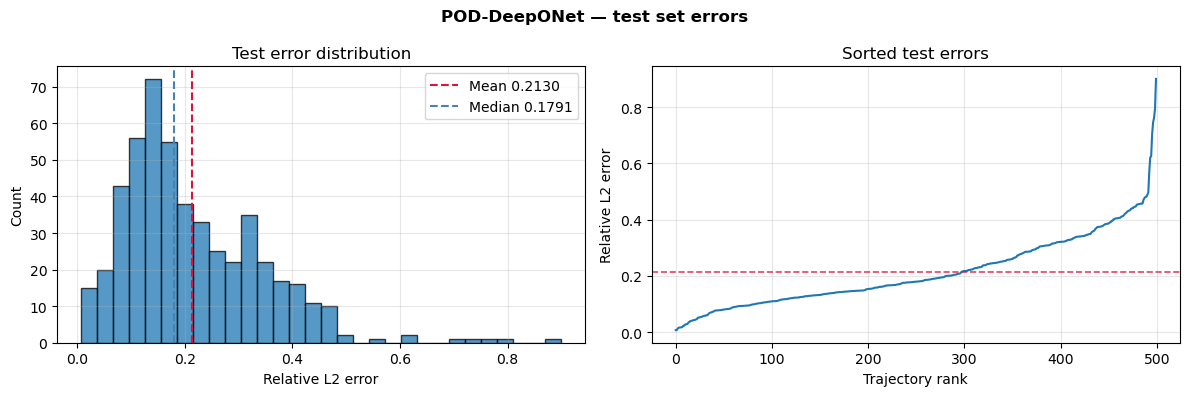

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(err_test, bins=30, edgecolor='k', alpha=0.75)
ax.axvline(err_test.mean(),       color='crimson',   ls='--', lw=1.5, label=f'Mean {err_test.mean():.4f}')
ax.axvline(np.median(err_test),   color='steelblue', ls='--', lw=1.5, label=f'Median {np.median(err_test):.4f}')
ax.set_xlabel('Relative L2 error')
ax.set_ylabel('Count')
ax.set_title('Test error distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(np.sort(err_test), lw=1.5)
ax.axhline(err_test.mean(), color='crimson', ls='--', lw=1.2, alpha=0.8)
ax.set_xlabel('Trajectory rank')
ax.set_ylabel('Relative L2 error')
ax.set_title('Sorted test errors')
ax.grid(True, alpha=0.3)

plt.suptitle('POD-DeepONet — test set errors', fontweight='bold')
plt.tight_layout()
plt.show()